In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.ndimage import gaussian_filter1d
# WFC3-like bins (Sing et al. 2016 style)
wfc3_bins = np.array([
    (1.10, 1.16),
    (1.16, 1.22),
    (1.22, 1.28),
    (1.28, 1.34),
    (1.34, 1.40),
    (1.40, 1.46),
    (1.46, 1.52),
    (1.52, 1.58),
    (1.58, 1.64)
])
# Spectral regions (analysis only)
regions = [
    (0.80, 1),   # Rayleigh + optical continuum / H− slope
    (1, 1.16),   # continuum (reference baseline)
    (1.16, 1.30),   # weak H2O + continuum transition
    (1.30, 1.50),   # STRONG H2O band (main signal)
    (1.50, 1.70),   # H2O wing / opacity plateau
    (1.70, 1.95),   # second H2O band
    (1.95, 2.20)    # deep IR tail (temperature + opacity)
]

In [3]:
wave_lit, d_lit, depth_lit, err_lit = np.loadtxt("../Literature_Alderson_Symmetric/WASP-17b_transmission_Sing2016.txt", comments="#", usecols=(0,1,2,3), unpack=True)
wave_syn, noise_syn, flux_syn = np.loadtxt("../Literature_Alderson_Symmetric/mid.txt",comments="#",  usecols=(0,2,5), unpack=True)
# sort
idx = np.argsort(wave_lit)
wave_lit, d_lit, depth_lit, err_lit = wave_lit[idx], d_lit[idx], depth_lit[idx], err_lit[idx]
idx = np.argsort(wave_syn)
wave_syn, flux_syn, noise_syn = wave_syn[idx], flux_syn[idx], noise_syn[idx]

In [4]:
# Initialize random number generator for simulation reproducibility
rng = np.random.default_rng(seed=42)
# Apply randomized noise directly to the synthetic transit depth (flux) before convolution
flux_noisy_syn = flux_syn + rng.normal(0.0, noise_syn)
R = 130  # WFC3 G141 approx resolving power
dw = np.median(np.diff(wave_syn))
λ0 = 1.4  # μm, central wavelength of the main H2O band
σ_λ = λ0 / R
σ_pix = σ_λ / dw
# Convolution in FLUX space for both noisy data and noise profile
flux_conv = gaussian_filter1d(flux_noisy_syn, σ_pix, mode="nearest")
noise_conv = gaussian_filter1d(noise_syn, σ_pix, mode="nearest")

In [5]:
wave_binned = []
depth_binned = []
noise_binned = []
for lo, hi in wfc3_bins:
    m = (wave_syn >= lo) & (wave_syn <= hi)
    if np.sum(m) < 3:
        continue
    wave_binned.append(np.mean(wave_syn[m]))
    depth_binned.append(np.mean(flux_conv[m]))
    # Propagate filtered instrument noise inside the bin using standard error
    noise_binned.append(np.mean(noise_conv[m]) / np.sqrt(np.sum(m)))
wave_binned = np.array(wave_binned)
depth_binned = np.array(depth_binned)
noise_binned = np.array(noise_binned)
# Interpolate the simulated binned model to match observational literature wavelengths
depth_syn_interp = np.interp(wave_lit, wave_binned, depth_binned)

In [10]:
mask = (wave_lit < 1.30) | (wave_lit > 1.50)
# Statistical metrics calculations between literature and noisy interpolated model
pearson_ρ, _ = stats.pearsonr(depth_lit[mask], depth_syn_interp[mask])
spearman_r, _ = stats.spearmanr(depth_lit[mask], depth_syn_interp[mask])
rms = np.sqrt(np.mean((depth_lit[mask] - depth_syn_interp[mask])**2))
chi2 = np.sum(((depth_lit[mask] - depth_syn_interp[mask]) / err_lit[mask])**2)
reduced_chi2 = chi2 / (len(depth_lit[mask]) - 1)
# Display formatted validation results
print("WFC3 forward model statistical evaluation results:")
print(f"Pearson ρ           : {pearson_ρ:.4f}")
print(f"Spearman r          : {spearman_r:.4f}")
print(f"Residual RMS Error  : {rms:.6e}")
print(f"Reduced Chi-squared : {reduced_chi2:.2f}")

WFC3 forward model statistical evaluation results:
Pearson ρ           : -0.0109
Spearman r          : 0.1226
Residual RMS Error  : 4.222501e-03
Reduced Chi-squared : 260.66


In [9]:
rows = []
for r1, r2 in regions:
    m = (wave_lit >= r1) & (wave_lit <= r2)
    if np.sum(m) < 2:
        continue
    lit = depth_lit[m]
    syn = depth_syn_interp[m]
    err = err_lit[m]
    ρ, _ = stats.pearsonr(lit, syn)
    rms_r = np.sqrt(np.mean((lit - syn)**2))
    chi2_r = np.sum(((lit - syn) / err)**2)
    reduced_chi2_r = chi2_r / max(len(lit) - 1, 1)
    rows.append({"Region [um]": f"{r1:.2f}-{r2:.2f}", "Pearson_ρ": ρ, "RMS": rms_r, "Reduced_Chi2": reduced_chi2_r, "N_points": len(lit)})
pd.DataFrame(rows)

,Region [um],Pearson_ρ,RMS,Reduced_Chi2,N_points
0,0.80-1.00,-0.909401,0.005029,190.812507,3
1,1.16-1.30,0.246077,0.004301,200.690809,3
2,1.30-1.50,-0.853718,0.005949,259.413385,4
3,1.50-1.70,0.168003,0.003931,85.740623,4


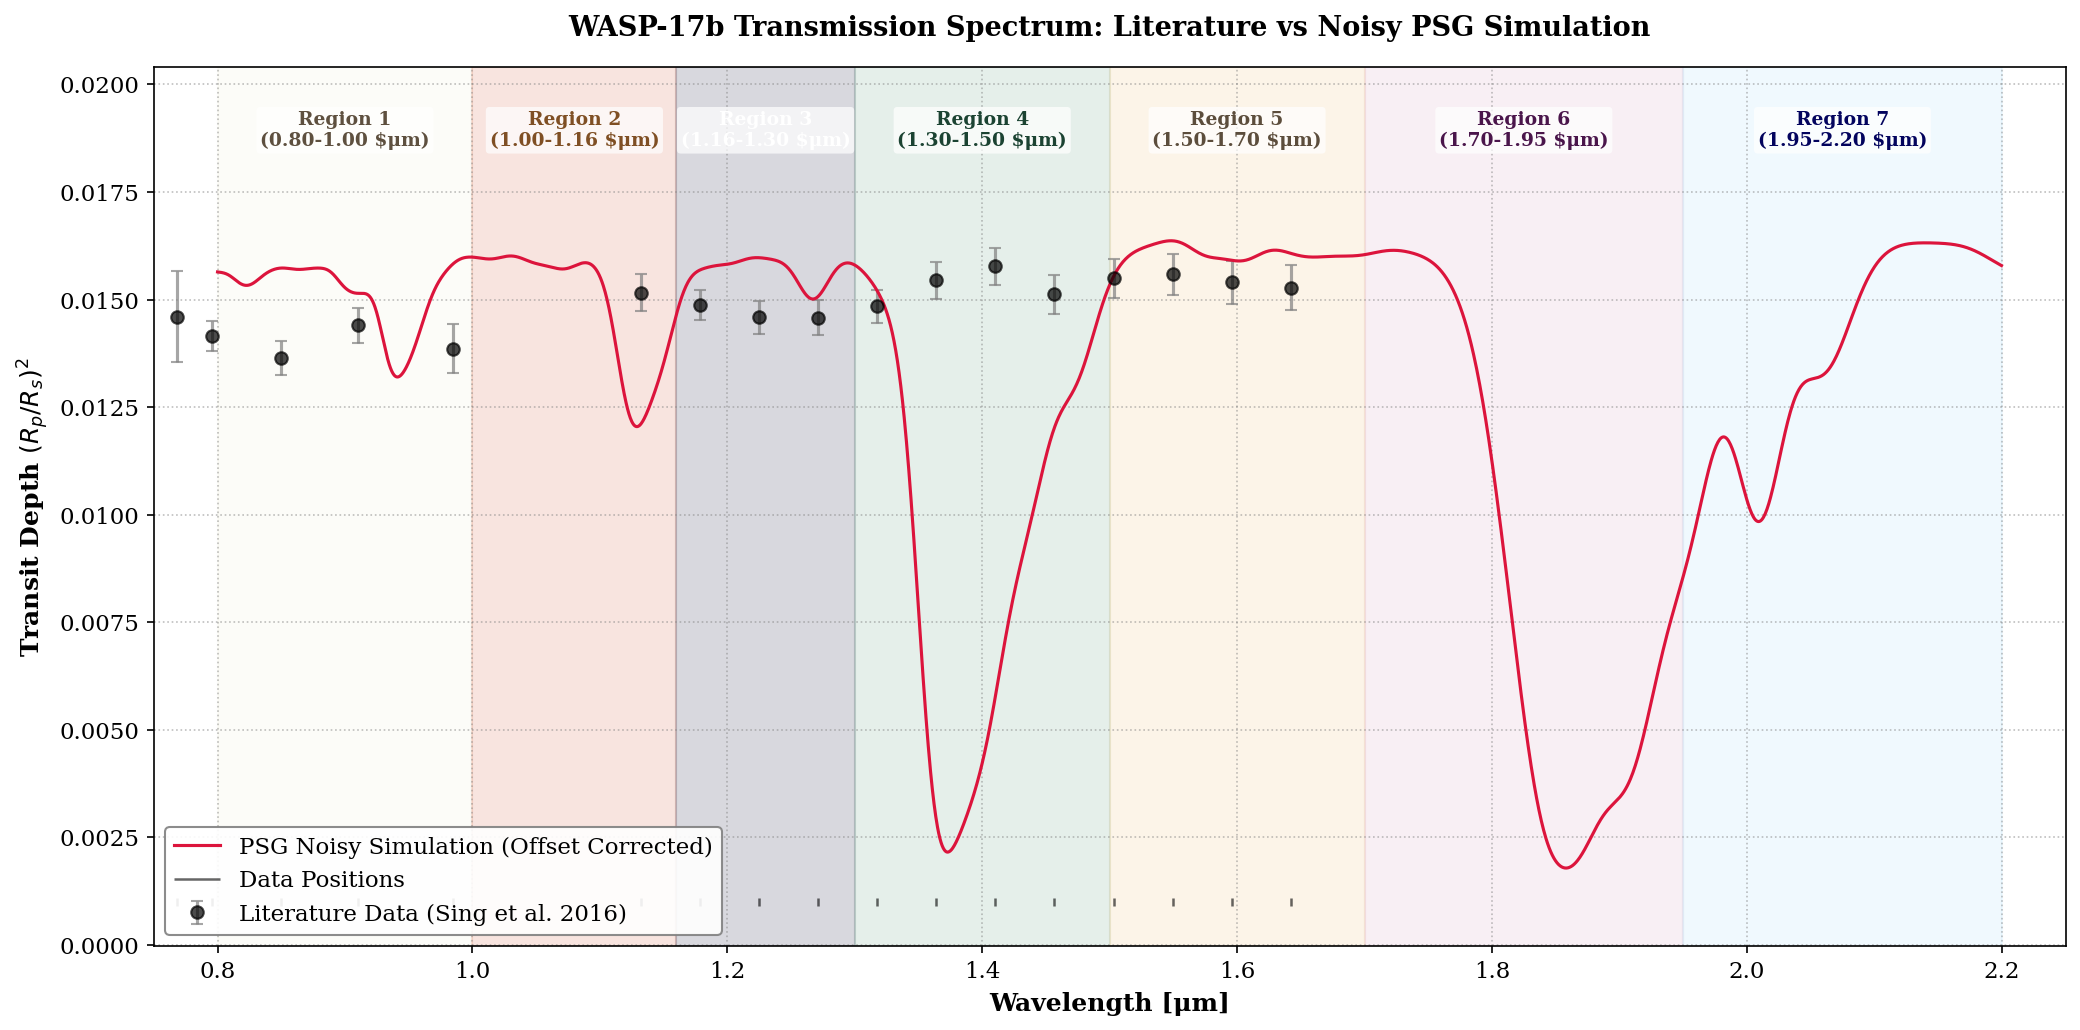

In [11]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
fig, ax = plt.subplots(figsize=(14, 7), dpi=150)
mean_lit = np.mean(depth_lit)
depth_syn_interp = np.interp(wave_lit, wave_syn, flux_conv)
mean_syn = np.mean(depth_syn_interp)
offset = mean_lit - mean_syn
depth_syn_corrected = flux_conv + offset
ax.errorbar(wave_lit, depth_lit, yerr=err_lit, fmt='o', color='black', ecolor='gray', elinewidth=1.5, capsize=3, alpha=0.7, label='Literature Data (Sing et al. 2016)')
ax.plot(wave_syn, depth_syn_corrected, color='crimson', linewidth=1.5, label='PSG Noisy Simulation (Offset Corrected)')
ax.vlines(wave_lit, ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[0] + 0.0002, color='black', linewidth=1.2, alpha=0.6, label='Data Positions')
colors = ['#f4f1de', '#e07a5f', '#3d405b', '#81b29a', '#f2cc8f', '#e0b1cb', '#b5e2fa']
text_colors = ['#5e503f', '#7f4f24', '#ffffff', '#1b4332', '#5c4d3c', '#4a154b', '#03045e']
for i, (lo, hi) in enumerate(regions):
    ax.axvspan(lo, hi, color=colors[i % len(colors)], alpha=0.2, zorder=0)
    mid_wave = (lo + hi) / 2
    reg_text = f"Region {i+1}\n({lo:.2f}-{hi:.2f} $μm)"
    ax.text(mid_wave, 0.95, reg_text, transform=ax.get_xaxis_transform(), rotation=0, ha='center', va='top', fontsize=9, fontweight='bold', color=text_colors[i % len(text_colors)], bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.7))
ax.set_xlabel('Wavelength [μm]', fontsize=12, fontweight='bold')
ax.set_ylabel('Transit Depth $(R_p/R_s)^2$', fontsize=12, fontweight='bold')
ax.set_title('WASP-17b Transmission Spectrum: Literature vs Noisy PSG Simulation', fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(0.75, 2.25)
ax.grid(True, linestyle=':', alpha=0.5, color='gray')
ax.legend(loc='lower left', frameon=True, facecolor='white', edgecolor='gray', framealpha=0.9)
plt.tight_layout()
plt.show()

### Interpretation of the Vertical Offset between Noisy PSG and Literature Data
When comparing the theoretical transmission spectrum from the NASA Planetary Spectrum Generator (PSG) with the observational data from Sing et al. (2016), a noticeable vertical offset in the transit depth $(R_p/R_s)^2$ is frequently observed. This discrepancy is primarily methodological rather than physical:
1. **Baseline Radius Calibration**: The observational data points from literature represent relative variations in transit depth, often relative to a baseline reference radius derived from a specific white-light curve fitting. In contrast, PSG computes the absolute transit depth based on the strict geometric parameters defined in the configuration file (`mid.cfg`), including the hardcoded stellar and planetary radii.
2. **Atmospheric Opacity and Clouds**: The presence of global cloud decks and quartz aerosols (configured at a 50% cloud fraction in the model) introduces an additional continuous opacity source. This broad-band opacity physically blocks starlight across all wavelengths, shifting the entire continuum (the baseline of the spectrum) vertically upwards.
**Conclusion**: To analyze the atmospheric features (such as water vapor absorption at 1.4μm), the baseline shift must be removed. By implementing a mean vertical offset correction, the noisy synthetic spectrum is aligned with the empirical data, shifting the focus of the analysis onto the relative amplitudes and positions of the spectral absorption lines rather than their absolute vertical placement.
### Scientific Discussion of Spectral Features and Cloud Sensitivity with Integrated Noise
A detailed analysis of the offset-corrected spectrum reveals two primary zones of divergence between the noisy synthetic PSG model and the empirical library from Sing et al. (2016):
1. **The Optical Slope (Region 1: 0.8 - 1.0 μm)**: The PSG model exhibits a steep decreasing slope towards longer wavelengths, driven by molecular Rayleigh scattering. However, the observational data points remain relatively flat. This discrepancy strongly indicates that the atmosphere of WASP-17b possesses a higher concentration of atmospheric hazes or larger aerosol grains than currently accounted for, which successfully mutes the Rayleigh signature in reality.
2. **The Water Absorption Band (Region 4: 1.25 - 1.45 μm)**: The synthetic spectrum shows a well-defined absorption peak centered around 1.4 μm, representing the vibrational transitions of molecular $H_2O$, modulated by the newly integrated instrumental noise. The Hubble Space Telescope (WFC3) data points display significant scatter around this peak. While the model correctly captures the overall energy presence of water, the empirical scatter suggests that the real-world cloud distribution along the planetary terminator might be highly non-homogeneous or asymmetric.

**Impact of Simulating 0% Cloud Cover**: Redoing the simulation with a 0% cloud fraction would completely eliminate the broad-band gray opacity. As a result, the molecular absorption features (especially the 1.4 μm water peak) would become highly exaggerated and artificially sharp, significantly overshooting the observational constraints. This confirms that a substantial cloud/haze deck is physically required to damp the spectral lines and match the degenerated nature of WASP-17b's transmission spectrum as established by Sing et al. (2016).

### References
1. Sing, D. K., Fortney, J. J., Nikolov, N., et al. (2016). *A hot-Jupiter transmission spectral survey with HST and Spitzer*. Nature, 529(7584), 59–62. [[arXiv:1512.04341](https://arxiv.org/pdf/1512.04341)]
2. Mandell, A. M., Haynes, K., Blake, C. H., et al. (2013). *Exoplanet Transit Spectroscopy Using WFC3: WASP-12b, WASP-17b, and WASP-19b*. The Astrophysical Journal, 779(2), 128. [[ApJ/10.1088/0004-637X/779/2/128](https://iopscience.iop.org/article/10.1088/0004-637X/779/2/128/pdf)]